In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.methods import RVPermutationTest
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import plot_grid, plot_with_bands, plot_heatmap
import ast
import numpy as np
from functools import partial

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}

plt.rcParams.update(rcparams)

In [3]:

colors = {
    'DistanceCorrelation':'#E69F00' ,
    'ObservedCVM':'#0072B2',
    'QAP':'#D55E00',
    'RVPermutationTest':'#009E73',
}


linestyles = {
    'RVPermutationTest': '-',
    'DistanceCorrelation': '--',
    'QAP': '-.',
    'ObservedCVM': ':',
}
plotting_function = partial(plot_with_bands, colors=colors, linestyles=linestyles)

In [4]:
results1 = pd.read_csv("simulation_results_20260320_1534.csv")

In [5]:
results1.head()

,ComputeAll,args,n,k,edge_var,approximation,dgp,solver,rho,method,marginals
0,"{'Rejection': False, 'FalseRejection': False, ...","{'approximation': 'F-distr', 'copula_type': 'g...",100,3,1,F-distr,GaussianNetwork,ASE,0.2,DiffusionCorrelation,NaN
1,"{'Rejection': False, 'FalseRejection': False, ...","{'approximation': 'F-distr', 'copula_type': 'g...",100,3,3,F-distr,GaussianNetwork,ASE,0.2,DiffusionCorrelation,NaN
2,"{'Rejection': True, 'FalseRejection': False, '...","{'approximation': 'F-distr', 'copula_type': 'g...",300,3,1,F-distr,BernoulliNetwork,pgd_fit_wrapper,0.2,RVPermutationTest_latent,NaN
3,"{'Rejection': False, 'FalseRejection': False, ...","{'approximation': 'F-distr', 'copula_type': 'g...",200,3,1,F-distr,GaussianNetwork,ASE,0.0,DiffusionCorrelation,NaN
4,"{'Rejection': True, 'FalseRejection': False, '...","{'approximation': 'F-distr', 'copula_type': 's...",200,3,1,F-distr,BernoulliNetwork,pgd_fit_wrapper,0.2,RVPermutationTest_latent,NaN


In [6]:
# null hp
# results2 = pd.read_csv("simulation_results_20260325_1649.csv")

In [7]:
# results3 = pd.read_csv("simulation_results_20260320_1708.csv")

In [8]:
# esults4 = pd.read_csv("simulation_results_20260321_1436.csv")

In [9]:
# results1 = pd.read_csv("simulation_results_20260311_1610.csv")

In [10]:
# null hp
# results2 = pd.read_csv("simulation_results_20260312_0828.csv")

In [11]:
# block independence
# results3 = pd.read_csv("simulation_results_20260312_2242.csv")

In [12]:
# QAP
# results7 = pd.read_csv("simulation_results_20260313_1059.csv")

In [13]:
# results8 = pd.read_csv("simulation_results_20260313_1538.csv")

In [14]:
# results9 = pd.read_csv("simulation_results_20260316_1217.csv")

In [16]:
results_concat =results1.copy()

In [17]:
import re

def parse_config_string(s):
    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # extract method class specifically from the 'method' field (not globally)
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)
        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split('.')[-1]
        fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        if fm:
            test_function = fm.group(1)

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    # extract solver: handle both plain string and <function Name at 0x...>
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)
    
    #extract degree 
    pairs['degree'] = re.search(r"degree=(\d+)", s).group(1) if re.search(r"degree=(\d+)", s) else "NA"

    return pairs

In [18]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [19]:
results = results_concat.copy()
results['args'] = results['args'].apply(parse_config_string)

In [20]:
results['ComputeAll'] = results['ComputeAll'].apply(parse_result_string)

In [21]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results['n'] = results['args'].apply(lambda x: x.get("n", "NA"))
results['k'] = results['args'].apply(lambda x: x.get("k", "NA"))
results['method'] = results['args'].apply(lambda x: x.get("method", "NA").strip("'"))
results['solver'] = results['args'].apply(lambda x: x.get("solver", "NA").strip("'"))
results['copula'] = results['args'].apply(lambda x: x.get("copula_type", "NA").strip("'"))
results['dgp_name'] = results['args'].apply(lambda x: x.get("dgp_name", "NA").strip("'"))
results['marginals'] = results['args'].apply(lambda x: x.get("marginals", "NA").strip("'"))
results['rho'] = results['args'].apply(lambda x: x.get("rho", "NA").replace('np.float64(', '').replace(')', ''))
results['rho'] = results['rho'].apply(lambda x: float(x))
results['degree'] = results['args'].apply(lambda x: x.get("degree", "NA").replace('np.int64(', '').replace(')', ''))

In [22]:
results['n'] = results['n'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))
results['k'] = results['k'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))

In [23]:
results_all = results.copy()

In [24]:
# results_all["dgp"] = results_all["args"].apply(lambda x: x.get("dgp_name", "NA"))
# results_all['dgp_name'] =  [x.split('_')[0].strip("'") for x in results_all['dgp']]
# results_all['copula'] =  [x.split('_')[1].strip("'") for x in results_all['dgp']]

In [25]:
# temp = results_all[results_all['method']=='QAP'].copy()

# temp["dgp"] = temp["args"].apply(lambda x: x.get("dgp_name", "NA"))
# temp['dgp_name'] =  [x.split('_')[0].strip("'") for x in temp['dgp']]
# temp['copula'] =  [x.split('_')[1].strip("'") for x in temp['dgp']]

# results_all[results_all['method']=='QAP']=temp.copy()

In [26]:
# temp = results_all[results_all['method']=='ObservedCVM'].copy()

# temp["dgp"] = temp["args"].apply(lambda x: x.get("dgp_name", "NA"))
# temp['dgp_name'] =  [x.split('_')[0].strip("'") for x in temp['dgp']]
# temp['copula'] =  [x.split('_')[1].strip("'") for x in temp['dgp']]
# # temp['method'] = temp['method'] + '_' +temp['degree']
# results_all[results_all['method']=='ObservedCVM']=temp.copy()

In [27]:
results_all["RelativeFrobeniusNorm_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results_all["RelativeFrobeniusNorm_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)

results_all['ProcrustesDistance_x'] = results_all['ComputeAll'].apply(lambda x: x.get('ProcrustesDistance_x', np.nan))
results_all['ProcrustesDistance_z'] = results_all['ComputeAll'].apply(lambda x: x.get('ProcrustesDistance_z', np.nan))

results_all["FalseRejection"] = results_all["ComputeAll"].apply(lambda x: x["FalseRejection"])
results_all["TrueRejection"] = results_all["ComputeAll"].apply(lambda x: x["TrueRejection"])
results_all["Rejection"] = results_all["ComputeAll"].apply(lambda x: x["Rejection"])

In [28]:
results_all['avg_rel_frob_x'] = (
    results_all
    .groupby(['n', 'method', 'marginals', 'copula', 'dgp_name'])['RelativeFrobeniusNorm_x']
    .transform('mean')
)

results_all['avg_proc_dist_x'] = (
    results_all
    .groupby(['n', 'method', 'marginals', 'copula', 'dgp_name'])['ProcrustesDistance_x']
    .transform('mean')
)

In [29]:
results_all['permutation_type'] = results_all['RelativeFrobeniusNorm_x'].apply(lambda x: 'observed' if np.isnan(x) else 'latent')
results_all['method'] = results_all['method'].replace({'DiffusionCorrelation':'DistanceCorrelation'})
results_all.rename(columns={'TrueRejection': 'Power'}, inplace=True)

In [30]:
results_all = results_all[results_all['edge_var']=='1']
results_all = results_all[~results_all['degree'].isin(['1', '3'])]

### Defining different aggregations

In [31]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [32]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == 0.5)].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == 0.2)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.5)].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.2)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [33]:
agg_null_gaussian = aggregate_results(results_null_gaussian,
                                      y_axis="FalseRejection",
                                      x_axis="n",
                                      factors=["marginals", "method", "permutation_type"])

agg_null_bernoulli = aggregate_results(results_null_bernoulli, 
                             y_axis="FalseRejection",
                             x_axis="n",
                             factors=["marginals", "method", "permutation_type"])

agg_null_gaussian_frob = aggregate_results(results_null_gaussian,
                                           y_axis="FalseRejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["marginals", "method", "permutation_type"])
agg_null_bernoulli_frob = aggregate_results(results_null_bernoulli,
                                           y_axis="FalseRejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["marginals", "method", "permutation_type"])

agg_null_gaussian_proc = aggregate_results(results_null_gaussian,
                                           y_axis="FalseRejection",
                                           x_axis="avg_proc_dist_x",
                                           factors=["marginals", "method", "permutation_type"])
agg_null_bernoulli_proc = aggregate_results(results_null_bernoulli,
                                           y_axis="FalseRejection",
                                           x_axis="avg_proc_dist_x",
                                           factors=["marginals", "method", "permutation_type"])

In [34]:
rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 17,
    "figure.titlesize": 17,
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
}

plt.rcParams.update(rcparams)

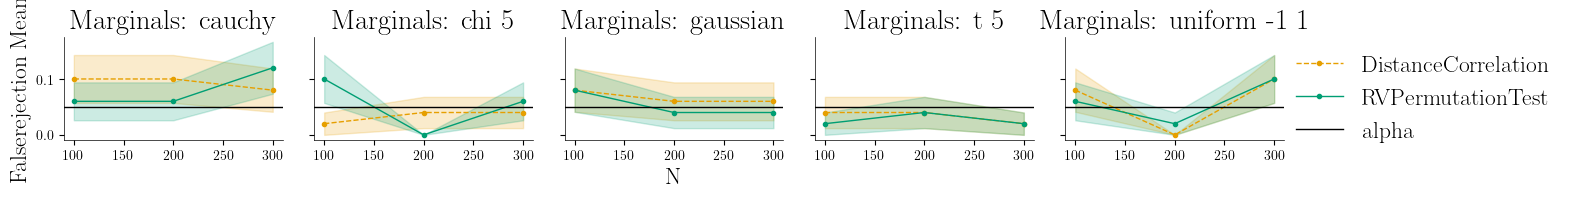

In [35]:
temp = agg_null_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals", "permutation_type"],
    height=2,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="",
    hline=0.05,
    hline_name="alpha",
    hide_row_titles=True
)

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals", "permutation_type"],
    height=2,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="",
    hline=0.05,
    hline_name="alpha",
    hide_row_titles=True,
    save_path='figures/false_rejection_rate_weighted_network'
)

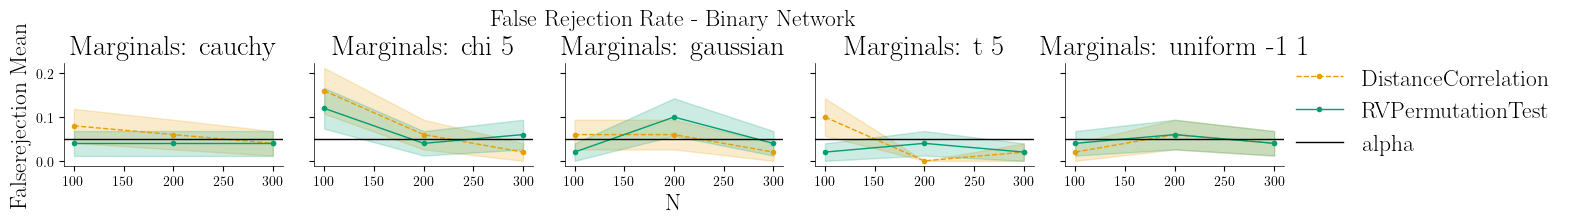

In [36]:
temp = agg_null_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals", "permutation_type"],
    height=2,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="False Rejection Rate - Binary Network",
    hline=0.05,
    hline_name="alpha",
    hide_row_titles=True
)

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals", "permutation_type"],
    height=2,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="",
    hline=0.05,
    hline_name="alpha",
    hide_row_titles=True,
    save_path='figures/false_rejection_rate_binary_network'
)


flipping


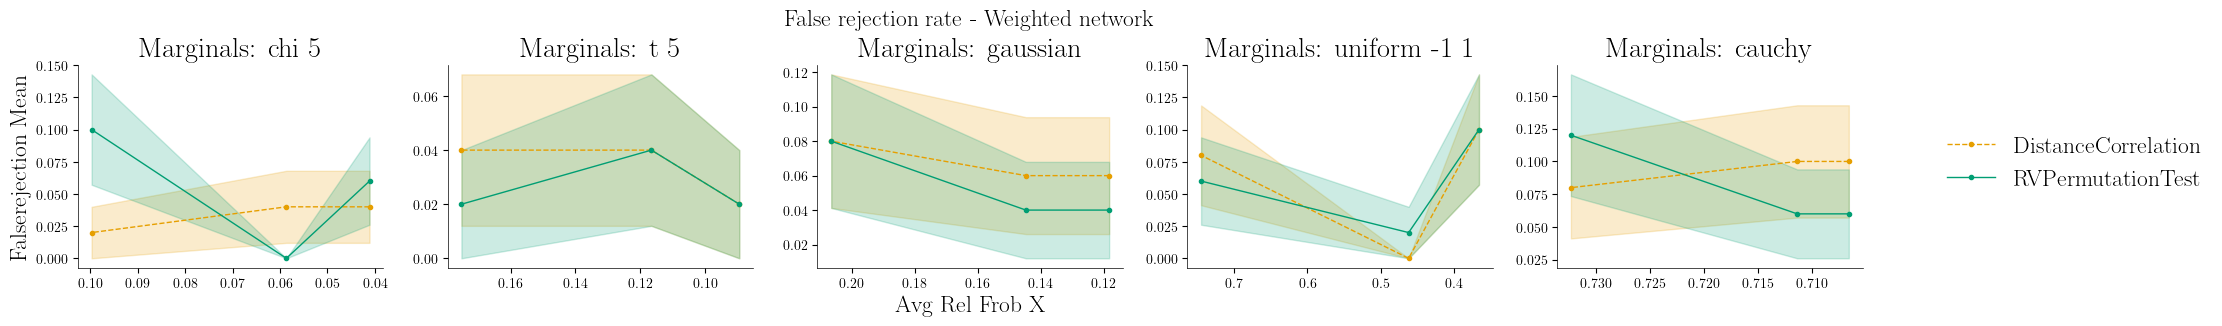

In [37]:
temp = agg_null_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

flipping


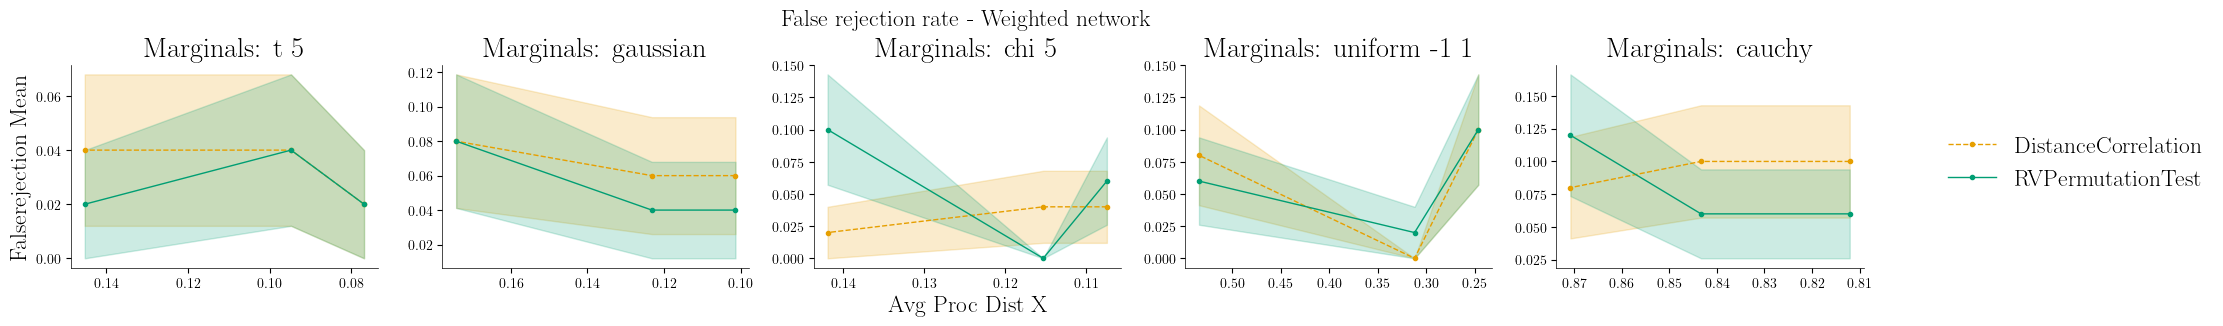

In [38]:
temp = agg_null_gaussian_proc.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_proc_dist_x",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

flipping


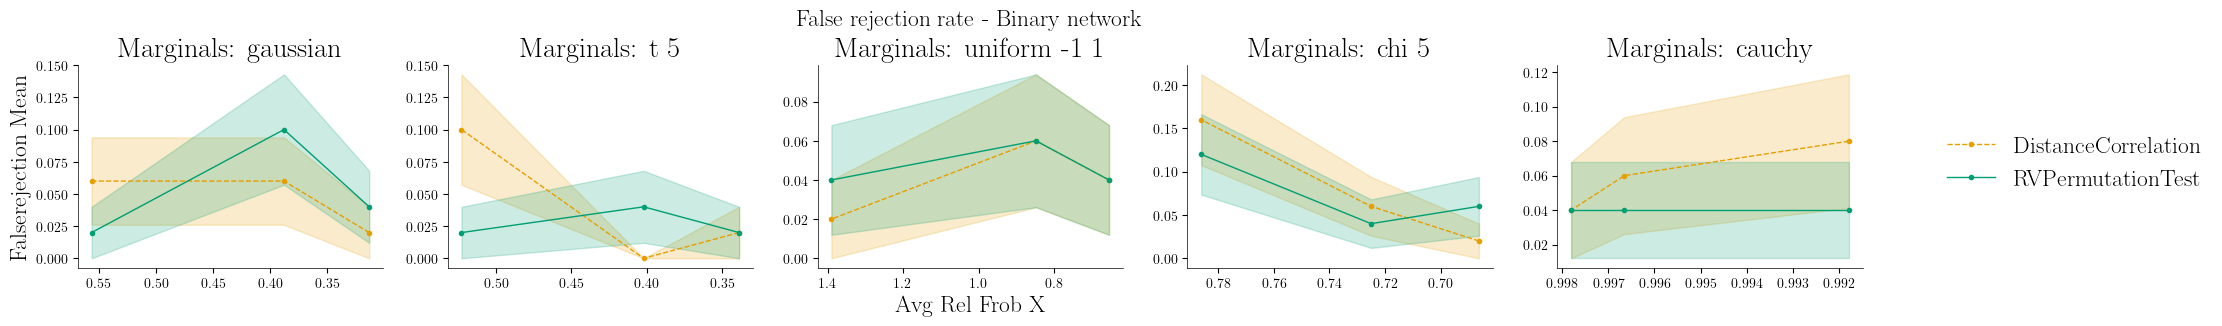

In [39]:
temp = agg_null_bernoulli_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Binary network",
    flip_x_axis=True,
)

flipping


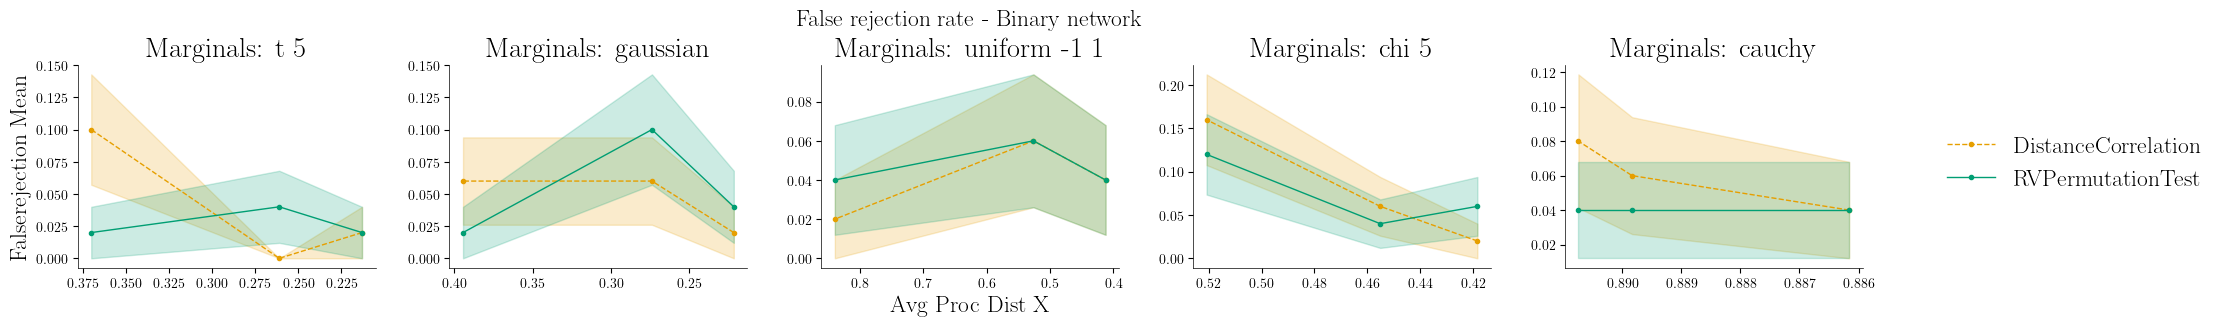

In [40]:
temp = agg_null_bernoulli_proc.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_proc_dist_x",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Binary network",
    flip_x_axis=True,
)

### Power

In [41]:
agg_alt_02_gaussian = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "copula"]
)
agg_alt_02_bernoulli = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "copula"]
)

agg_alt_02_gaussian_frob = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula"]
)

agg_alt_02_bernoulli_frob = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula"]
)

In [42]:
# different params for power plot

rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
}

plt.rcParams.update(rcparams)

In [43]:
import seaborn as sns
sns.set_context("talk", font_scale=1.2)

# 2. Update with your specific stylistic overrides
custom_params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}
plt.rcParams.update(custom_params)

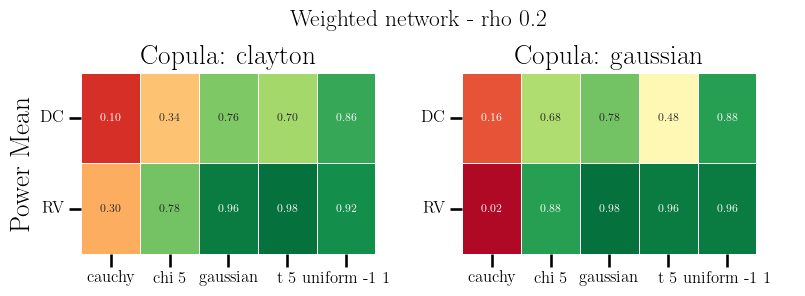

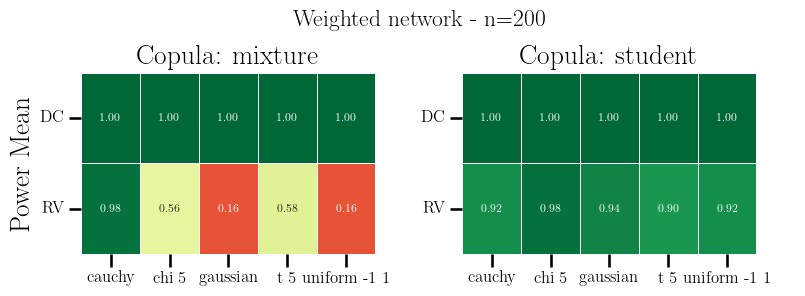

In [44]:
# small tail 
import seaborn as sns
sns.set_context("talk", font_scale=1.1)

custom_params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}
plt.rcParams.update(custom_params)

temp = agg_alt_02_gaussian.copy()
temp = temp[~temp['copula'].isin(['gumbel'])]
temp = temp[temp['n']==200]
temp.iloc[:, temp.columns.get_loc('method')] = temp['method'].replace({'DistanceCorrelation':'DC', 'ObservedCVM':'CVM', 'RVPermutationTest':'RV'})

plot_grid(
    grouped_stats=temp[temp['copula'].isin(['clayton', 'gaussian'])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
    name_conversion={'n':'n (Number of nodes)', 'marginals':''},
    show_row_names=False
)

plot_grid(
    grouped_stats=temp[~temp['copula'].isin(['clayton', 'gaussian'])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - n=200",
    name_conversion={'n':'n (Number of nodes)', 'marginals':''},
    show_row_names=False
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted network - rho 0.2",
#     name_conversion={'n':'n (Number of nodes)'},
#     save_path="figures/power_weighted_02_light_tails"
# )

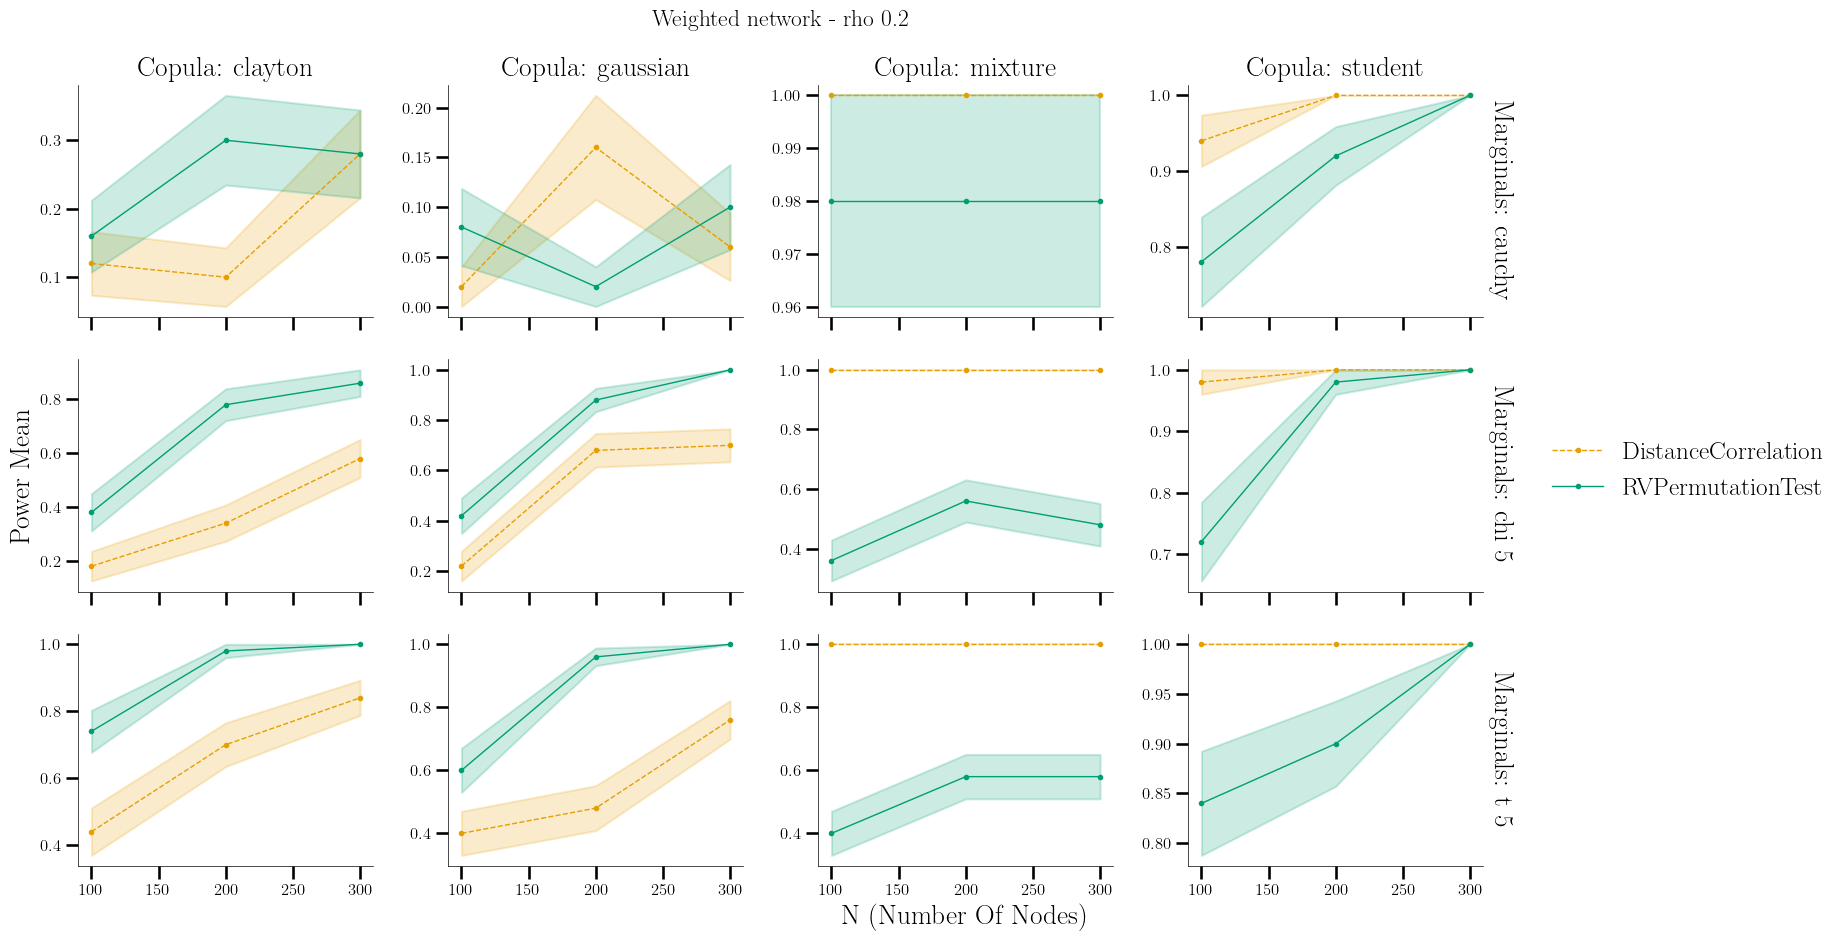

In [45]:
# heavy tails

temp = agg_alt_02_gaussian.copy()
temp = temp[~temp['copula'].isin(['gumbel'])]
temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
    name_conversion={'n':'n (Number of nodes)'}
)

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
    save_path="figures/power_weighted_02_heavy_tails"
)

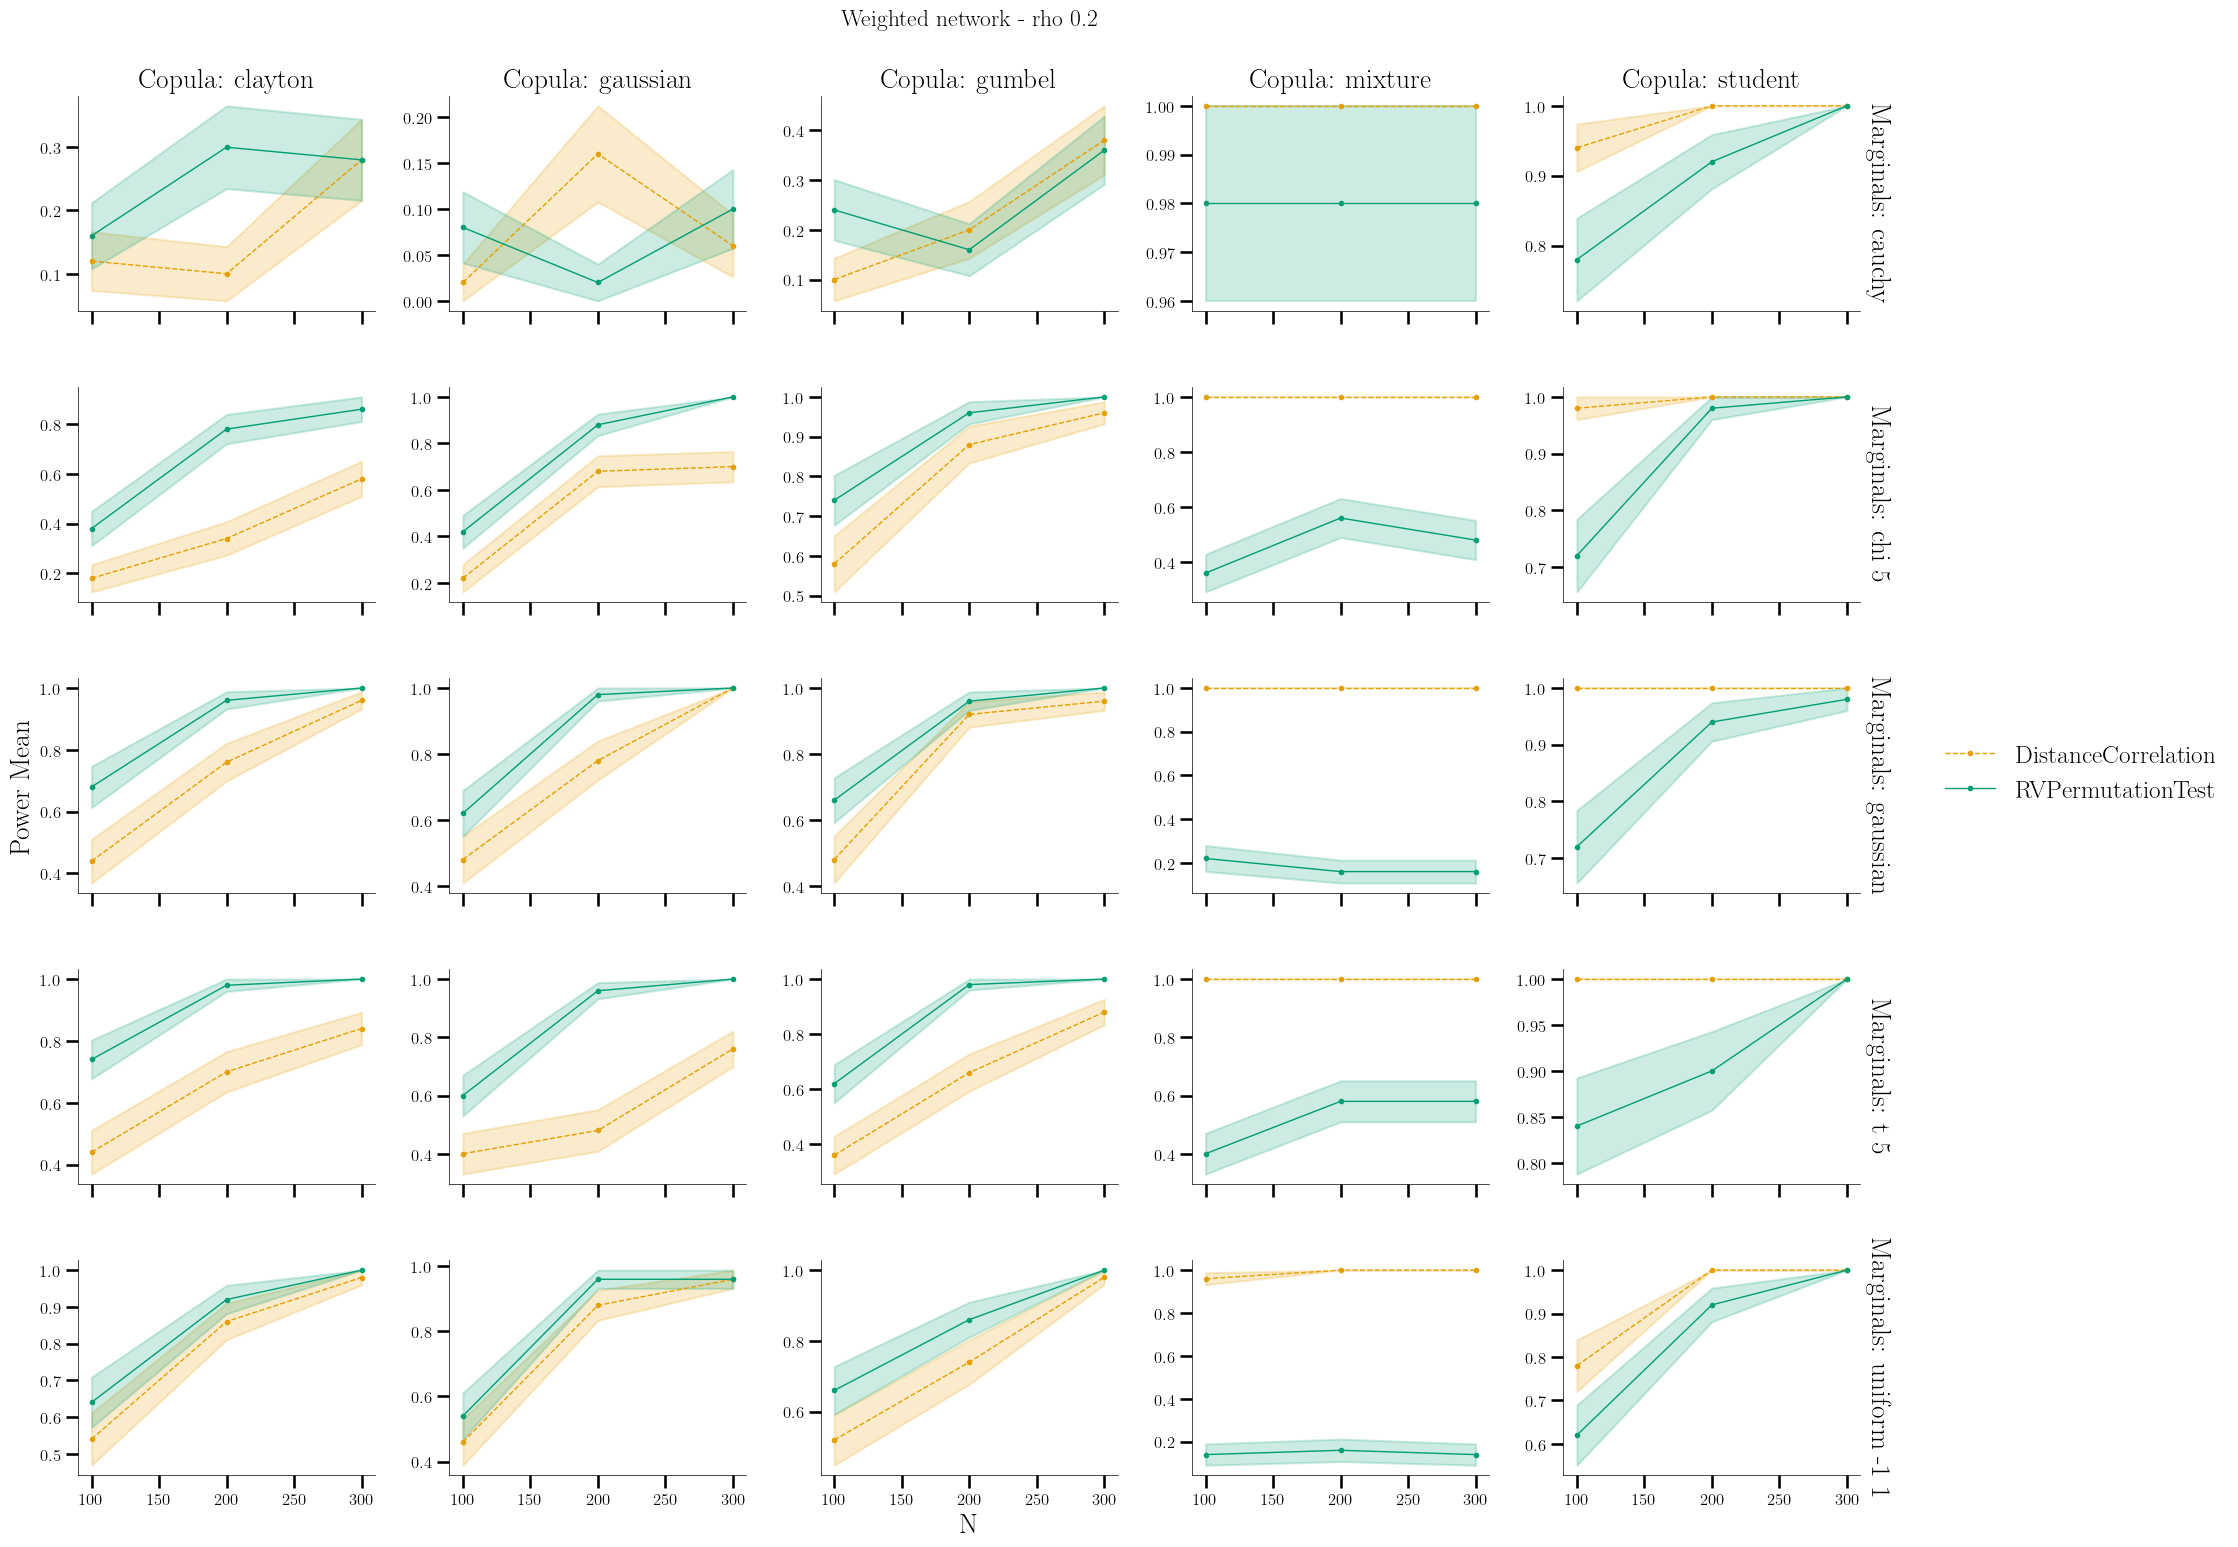

In [46]:
temp = agg_alt_02_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

In [47]:
# --- 2. QUANTIFYING SENSITIVITY ---
# Group by the factors that SHOULD keep power constant
grouped = agg_alt_02_gaussian.groupby(['n', 'copula', 'method'])['Power_mean']

# Calculate the max-min range of power across the marginals
sensitivity_df = grouped.agg(
    power_range=lambda x: x.max() - x.min(),
    power_std='std'
).reset_index()

# Find the overall sensitivity per method
method_ranking = sensitivity_df.groupby('method')[['power_range', 'power_std']].mean().sort_values('power_range')

print("Methods sorted by sensitivity to marginals (Lowest = Most Invariant):")
print(method_ranking)

Methods sorted by sensitivity to marginals (Lowest = Most Invariant):
                     power_range  power_std
method                                     
DistanceCorrelation     0.404000   0.166767
RVPermutationTest       0.610667   0.256716


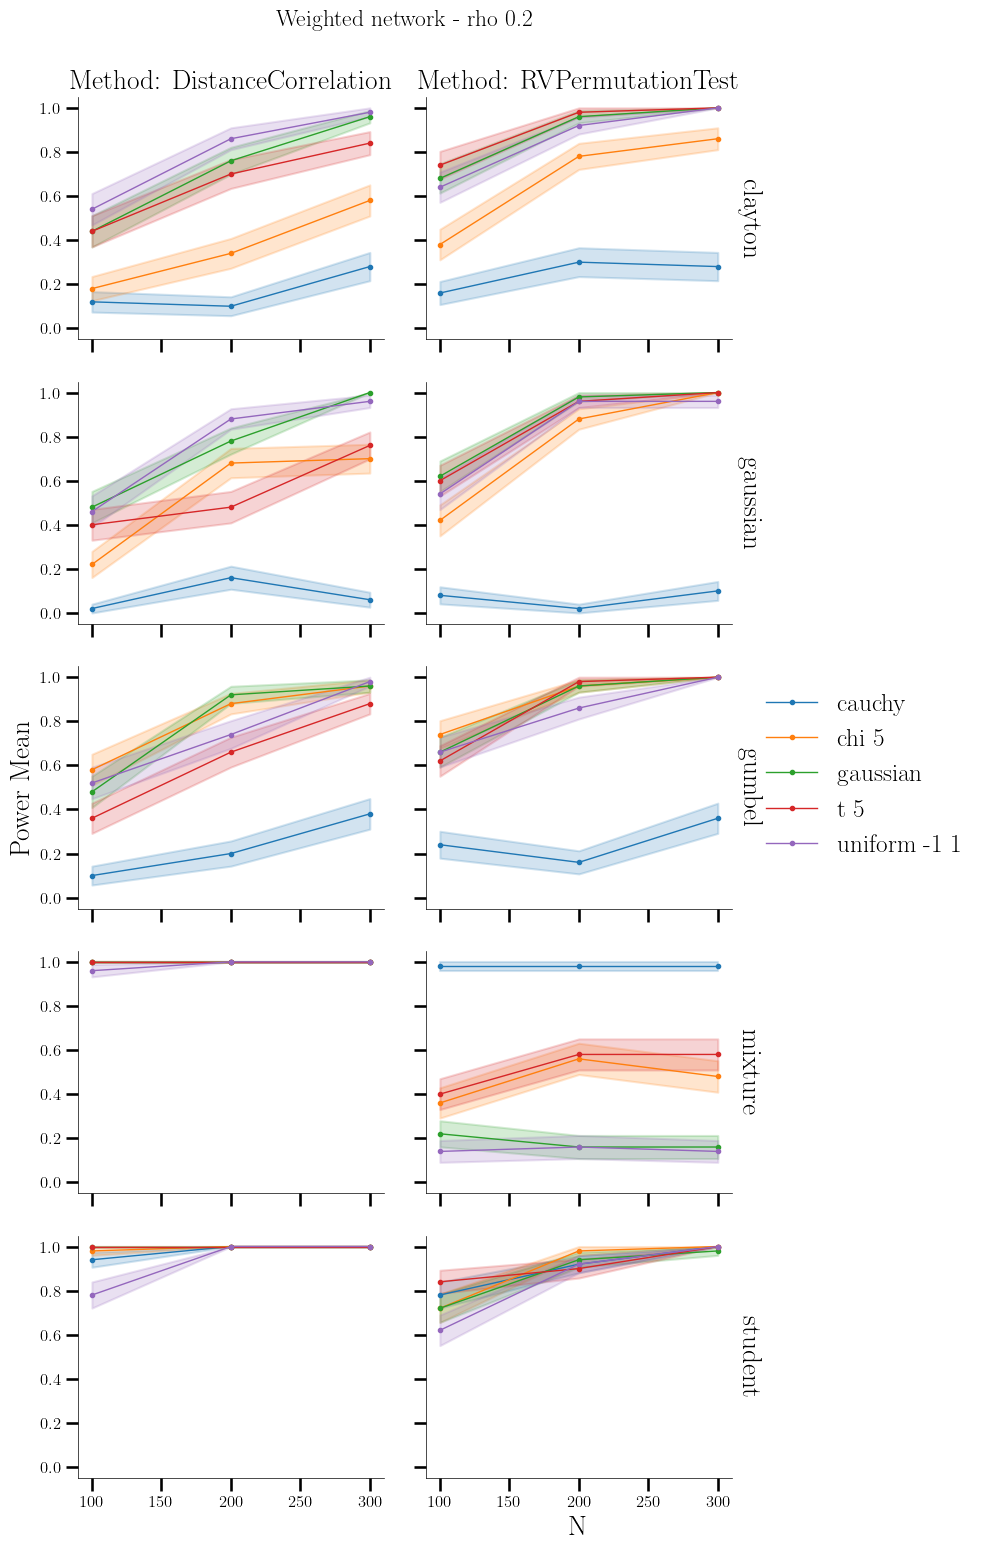

In [48]:
temp = agg_alt_02_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["marginals", "method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=True,
    title="Weighted network - rho 0.2",
    show_row_names=False
)

flipping


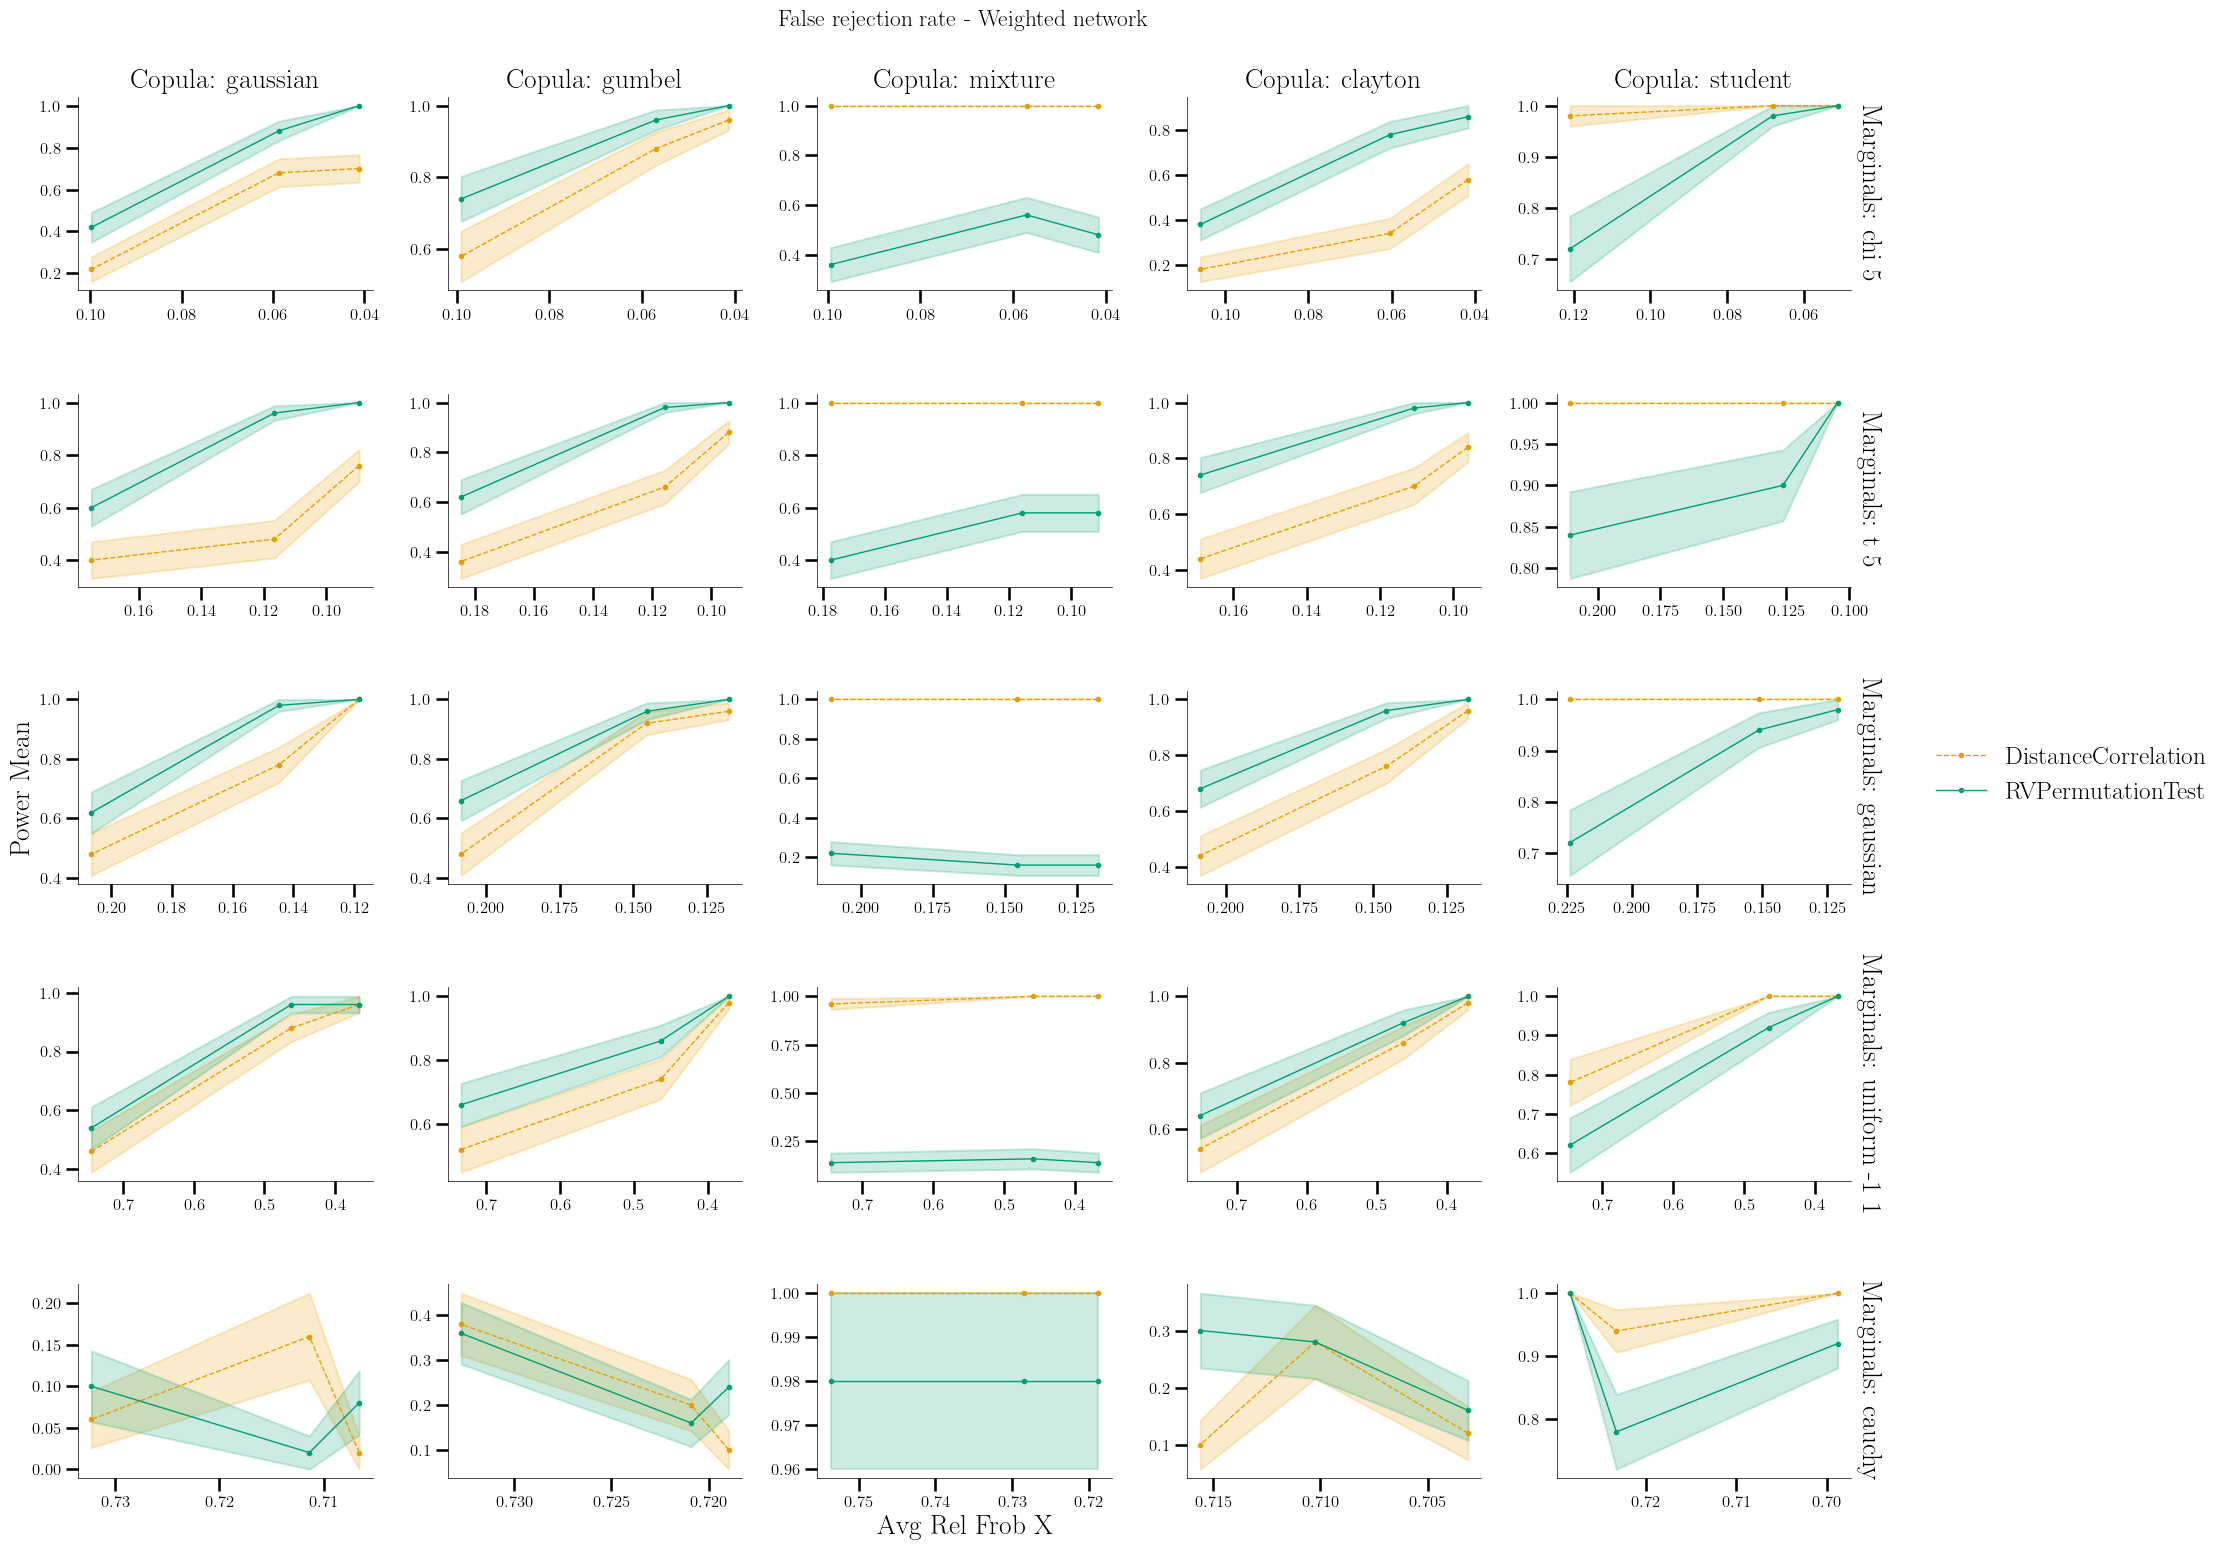

In [49]:
temp = agg_alt_02_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Power_mean",
    factors=["method", "copula","marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

### Binary network

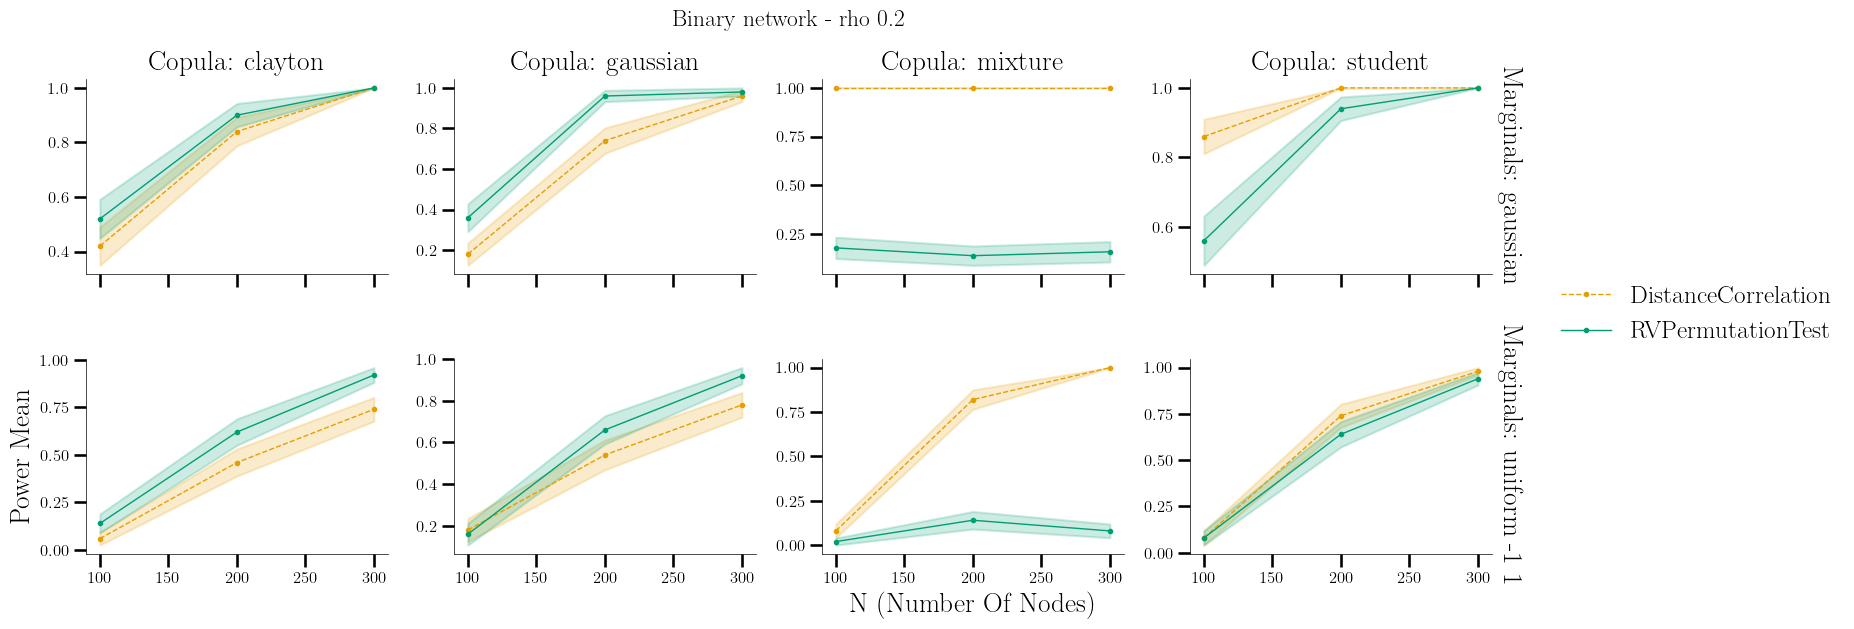

In [50]:
temp = agg_alt_02_bernoulli.copy()
temp = temp[~temp['copula'].isin(['gumbel'])]
temp = temp[temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
    name_conversion={'n':'n (Number of nodes)'}
)

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
    name_conversion={'n':'n (Number of nodes)'},
    save_path="figures/binary_network_rho_0_2_light_tails"
)

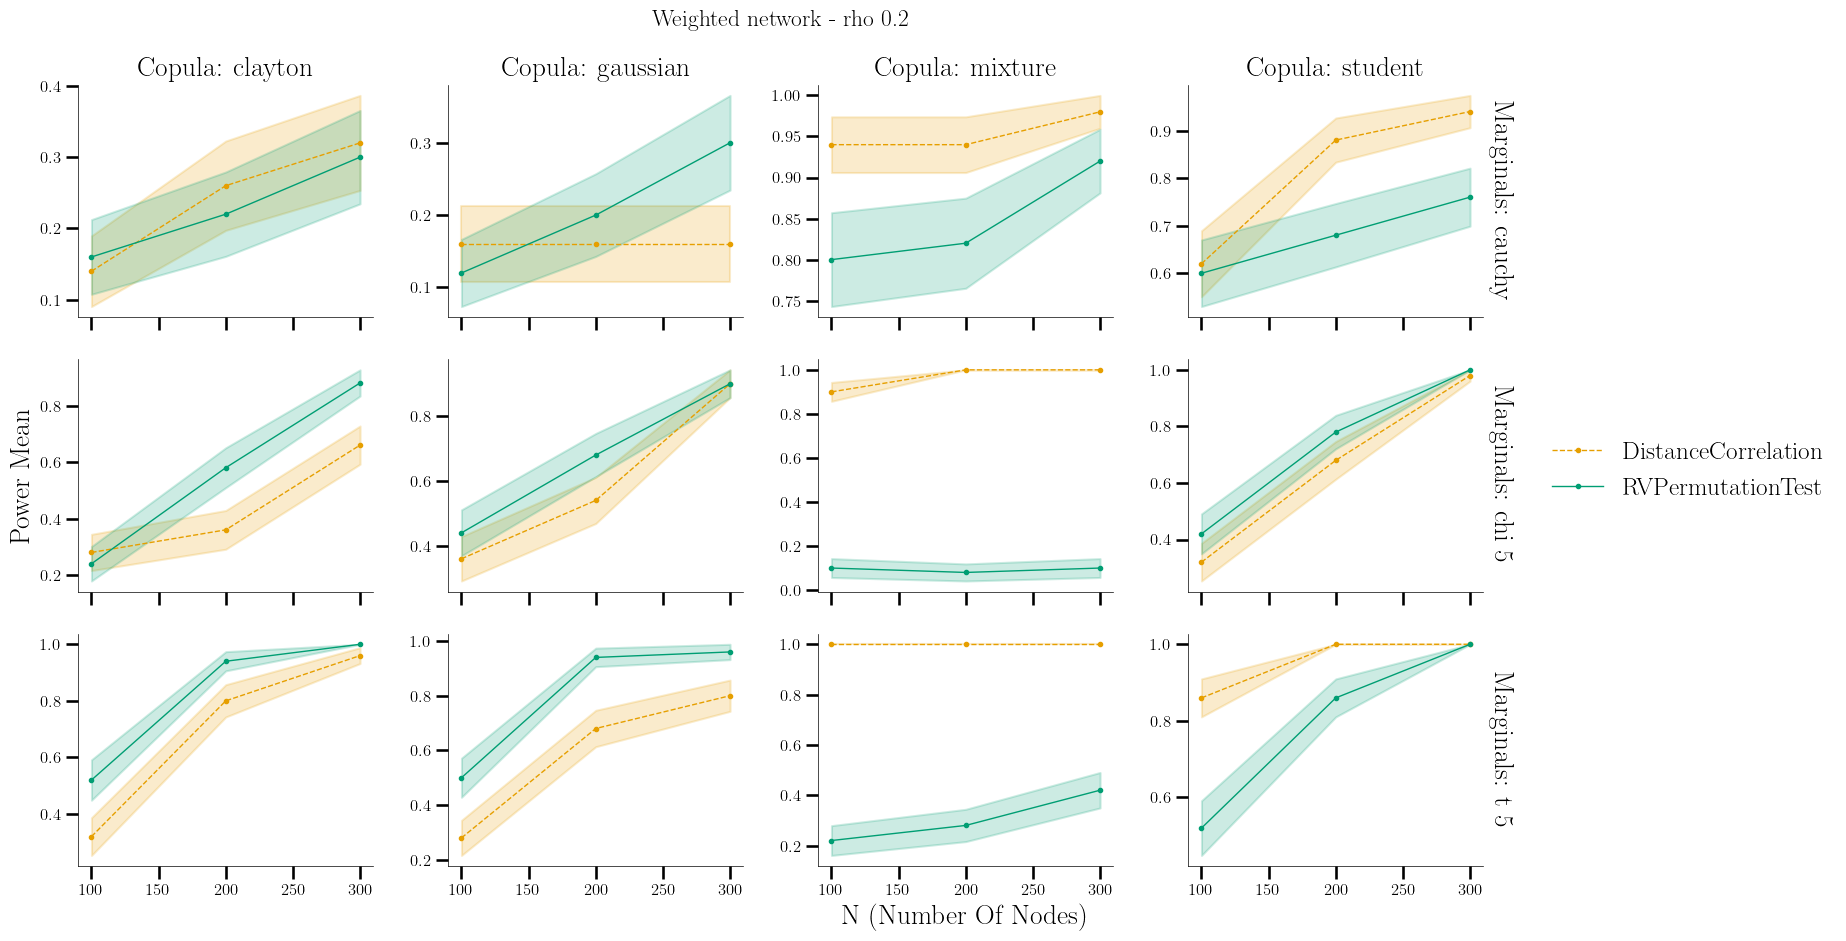

In [51]:
temp = agg_alt_02_bernoulli.copy()
temp = temp[~temp['copula'].isin(['gumbel'])]
temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
    name_conversion={'n':'n (Number of nodes)'}
)

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
    name_conversion={'n':'n (Number of nodes)'},
    save_path="figures/binary_network_rho_0_2_heavy_tails"
)

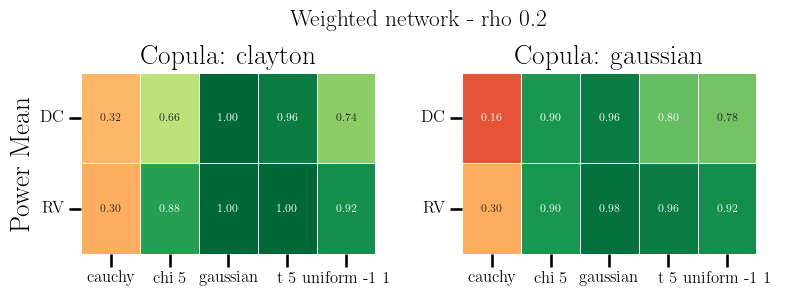

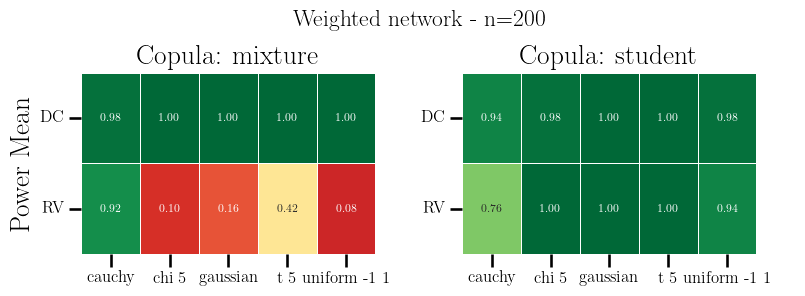

In [52]:
# small tail 
import seaborn as sns
sns.set_context("talk", font_scale=1.1)

custom_params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}
plt.rcParams.update(custom_params)

temp = agg_alt_02_bernoulli.copy()
temp = temp[~temp['copula'].isin(['gumbel'])]
temp = temp[temp['n']==300]
temp.iloc[:, temp.columns.get_loc('method')] = temp['method'].replace({'DistanceCorrelation':'DC', 'ObservedCVM':'CVM', 'RVPermutationTest':'RV'})

plot_grid(
    grouped_stats=temp[temp['copula'].isin(['clayton', 'gaussian'])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
    name_conversion={'n':'n (Number of nodes)', 'marginals':''},
    show_row_names=False
)

plot_grid(
    grouped_stats=temp[~temp['copula'].isin(['clayton', 'gaussian'])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - n=200",
    name_conversion={'n':'n (Number of nodes)', 'marginals':''},
    show_row_names=False
)

In [ ]:
temp = agg_alt_02_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
)


In [ ]:
temp = agg_alt_02_bernoulli_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Power_mean",
    factors=["method", "copula","marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Binary network",
    flip_x_axis=True,
)